# Wavelet Denoising — LAB_DDM Multi Dataset

Applies universal-threshold wavelet denoising (Donoho–Johnstone, `db4`) to raw kinetic curves  
from `POC_DDM_multi` or `POC_DDM_multi_nc_subtract`.

**Output:** one figure per experiment folder  
- **3 columns:** Raw | Smoothed (`ori_curves_avg`, moving-average from `01`) | Wavelet denoised  
- 1 row per well, labelled with class name  
- Metric annotation: SNR (dB), noise σ, noise % (same metric applied to both methods for comparison)

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pywt

sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code')
sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code/main')
import config

try:
    from tqdm import tqdm
except ImportError:
    tqdm = None

print(f'pywt {pywt.__version__} | base: {config.BASE_FOLDER}')


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

pywt 1.8.0 | base: /vol/bitbucket/gk225/POC_DDM_datasets


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATASET     = 'POC_DDM_multi_nc_subtract'   # or 'POC_DDM_multi'
EXP_FOLDER  = os.path.join(config.BASE_FOLDER, DATASET)
CURVE_TYPE  = 'ori_curves'
WAVELETS    = ['db4', 'db8', 'sym4', 'sym8', 'coif3']
WAVELETS    = ['sym8']
LEVEL       = None
THRESH_MODE = 'soft'


In [3]:
# ── Denoising functions ───────────────────────────────────────────────────────

def denoise_curve(curve, wavelet, level=LEVEL, mode=THRESH_MODE):
    coeffs    = pywt.wavedec(curve, wavelet, level=level)
    sigma     = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(curve)))
    new_coeffs = [coeffs[0]] + [pywt.threshold(d, threshold, mode=mode) for d in coeffs[1:]]
    return pywt.waverec(new_coeffs, wavelet)[:len(curve)]

def denoise_all(curves, wavelet):
    it = tqdm(curves, desc=f'Denoising [{wavelet}]', unit='curve') if tqdm else curves
    return np.array([denoise_curve(c, wavelet) for c in it])


def compute_metrics(raw, denoised):
    """
    Per-curve metrics:
      noise_std  — std of removed noise (original − denoised)
      noise_pct  — noise_std / signal_range × 100  (relative noise level)
      snr_db     — 10 log10(var(denoised) / var(noise))  (signal-to-noise ratio)
    """
    noise     = raw - denoised
    noise_std = np.std(noise, axis=1)
    sig_range = raw.max(axis=1) - raw.min(axis=1)
    noise_pct = np.where(sig_range > 0, noise_std / sig_range * 100, 0.0)
    var_d     = np.var(denoised, axis=1)
    var_n     = np.var(noise, axis=1)
    snr_db    = np.where(var_n > 0, 10 * np.log10(var_d / var_n), np.inf)
    return {'noise_std': noise_std, 'noise_pct': noise_pct, 'snr_db': snr_db}

In [4]:
# ── Data loading ──────────────────────────────────────────────────────────────

def list_folders(exp_folder):
    out = []
    for name in sorted(os.listdir(exp_folder)):
        p = os.path.join(exp_folder, name)
        cache = os.path.join(p, config.TRAINING_DATA_PATH)
        if (os.path.isdir(p)
                and name not in config.EXCLUDED_FOLDERS
                and os.path.exists(cache)):
            out.append((name, p))
    return out


def load_exp(folder_path):
    d = joblib.load(os.path.join(folder_path, config.TRAINING_DATA_PATH))
    curves     = np.array(d['curves'][CURVE_TYPE])          # (n_curves, n_timepoints)
    curves_avg = np.array(d['curves']['ori_curves_avg'])    # moving-average smoothed
    well_labels = np.array(d['well_labels'])                 # integer well index 0–9
    return curves, curves_avg, well_labels


folders = list_folders(EXP_FOLDER)
print(f'{DATASET}: {len(folders)} experiment folders')
for name, _ in folders:
    print(f'  {name}')

POC_DDM_multi_nc_subtract: 6 experiment folders
  D20260608_E00_C00_F4500KHz_U_norm_temp_04
  D20260609_E00_C00_F4500KHz_U_norm_temp_read_06
  D20260609_E00_C00_F4500KHz_U_norm_temp_read_07
  D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08
  D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01
  D20260624_E00_C00_F4500KHz_U_UTI_Trial_01_neg_test


In [5]:
from matplotlib.collections import LineCollection

_WAVELET_COLORS = ['#E69F00', '#CC79A7', '#56B4E9', '#D55E00', '#F0E442']
COL_COLORS = ['#0072B2', '#009E73'] + _WAVELET_COLORS[:len(WAVELETS)]

def plot_before_after(raw, smoothed, denoised_by_wavelet, well_labels, folder_name, label_map=None):
    """
    Columns: Raw | Smoothed | <one per wavelet in WAVELETS>
    denoised_by_wavelet: dict {wavelet_name: denoised_array}
    """
    unique_wells = sorted(np.unique(well_labels))
    n_rows = len(unique_wells)
    x      = np.arange(raw.shape[1])
    n_cols = 2 + len(WAVELETS)

    col_titles  = ['Raw', f'Smoothed\n(moving avg, w={config.WINDOW_SIZE_ORI})'] + \
                  [f'Wavelet\n({w})' for w in WAVELETS]
    col_data    = [raw, smoothed] + [denoised_by_wavelet[w] for w in WAVELETS]
    col_metrics = [None, compute_metrics(raw, smoothed)] + \
                  [compute_metrics(raw, denoised_by_wavelet[w]) for w in WAVELETS]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 2.8 * n_rows),
        sharey='row', squeeze=False
    )
    fig.suptitle(
        f'Denoising Comparison  —  {folder_name}\n({DATASET})',
        fontsize=11, fontweight='bold'
    )

    for row_i, well in enumerate(unique_wells):
        mask      = well_labels == well
        lname     = label_map.get(int(well), '?') if label_map else str(well)
        row_label = f'Well {well}  [{lname}]\nn={mask.sum()}'

        for col_i, (data_all, color, title, met) in enumerate(
                zip(col_data, COL_COLORS, col_titles, col_metrics)):
            ax     = axes[row_i, col_i]
            data_w = data_all[mask]
            mean   = data_w.mean(axis=0)

            segs = [np.column_stack([x, c]) for c in data_w]
            lc   = LineCollection(segs, colors=color, linewidths=0.1, alpha=0.05,
                                  zorder=2, rasterized=True)
            ax.add_collection(lc)
            ax.autoscale_view()
            ax.plot(x, mean, color="black", lw=2, zorder=3)
            ax.grid(alpha=0.3)

            if row_i == 0:
                ax.set_title(title, fontweight='bold', fontsize=9)
            if col_i == 0:
                ax.set_ylabel(row_label, fontsize=8.5, fontweight='bold')
            if row_i == n_rows - 1:
                ax.set_xlabel('Cycle', fontsize=9)

            if met is not None:
                m_snr  = met['snr_db'][mask].mean()
                m_npct = met['noise_pct'][mask].mean()
                m_nstd = met['noise_std'][mask].mean()
                ax.text(
                    0.98, 0.97,
                    f'SNR: {m_snr:.1f} dB\nNoise σ: {m_nstd:.5f}\nNoise %: {m_npct:.2f}%',
                    transform=ax.transAxes,
                    ha='right', va='top', fontsize=7.5,
                    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.9)
                )

    fig.tight_layout()
    plt.show()
    plt.close(fig)

def plot_sample_inspection(folder_name, n_samples=5, seed=42):
    r           = results[folder_name]
    raw         = r['raw']
    well_labels = r['well_labels']
    label_map   = r['label_map']

    col_labels = [f'Smoothed\n(moving avg, w={config.WINDOW_SIZE_ORI})'] + \
                 [f'Wavelet\n({w})' for w in WAVELETS]
    col_arrays = [r['smoothed']] + [r['denoised'][w] for w in WAVELETS]

    unique_wells = sorted(np.unique(well_labels))
    n_rows = len(unique_wells)
    n_cols = len(col_labels)
    x      = np.arange(raw.shape[1])
    rng    = np.random.default_rng(seed)

    # One colour per sample index, cycle if n_samples > palette length
    palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
    sample_colors = [palette[i % len(palette)] for i in range(n_samples)]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 2.8 * n_rows),
        sharey='row', squeeze=False
    )
    fig.suptitle(
        f'Sample Inspection  —  {folder_name}\n'
        f'({DATASET},  n={n_samples} samples/well  |  solid=raw, dashed=denoised)',
        fontsize=11, fontweight='bold'
    )

    for row_i, well in enumerate(unique_wells):
        mask    = well_labels == well
        indices = np.where(mask)[0]
        n       = min(n_samples, len(indices))
        sampled = rng.choice(indices, size=n, replace=False)

        lname     = label_map.get(int(well), '?') if label_map else str(well)
        row_label = f'Well {well}  [{lname}]\n(n={mask.sum()})'

        for col_i, (den_all, col_label) in enumerate(zip(col_arrays, col_labels)):
            ax = axes[row_i, col_i]

            for i, idx in enumerate(sampled):
                color = sample_colors[i]
                ax.plot(x, raw[idx],     color=color, lw=0.9, ls='-',  alpha=0.6, zorder=2)
                ax.plot(x, den_all[idx], color=color, lw=1.5, ls='--', alpha=0.9, zorder=3)

            ax.grid(alpha=0.3)

            if row_i == 0:
                ax.set_title(col_label, fontweight='bold', fontsize=9)
            if col_i == 0:
                ax.set_ylabel(row_label, fontsize=8.5, fontweight='bold')
            if row_i == n_rows - 1:
                ax.set_xlabel('Cycle', fontsize=9)

    # Shared legend for line style meaning
    legend_handles = [
        plt.Line2D([0], [0], color='gray', lw=0.9, ls='-',  label='Raw'),
        plt.Line2D([0], [0], color='gray', lw=1.5, ls='--', label='Denoised'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

    fig.tight_layout()
    plt.show()
    plt.close(fig)



In [6]:
label_maps = config.get_label_mappings(EXP_FOLDER)
results    = {}   # {folder_name: {raw, smoothed, denoised, well_labels, label_map}}

for folder_name, folder_path in folders:
    print(f'\n─── {folder_name} ───')
    try:
        raw, smoothed, well_labels = load_exp(folder_path)
        print(f'  curves: {raw.shape}')

        denoised_by_wavelet = {}
        for w in WAVELETS:
            denoised_by_wavelet[w] = denoise_all(raw, wavelet=w)

        results[folder_name] = {
            'raw':        raw,
            'smoothed':   smoothed,
            'denoised':   denoised_by_wavelet,
            'well_labels': well_labels,
            'label_map':  label_maps.get(folder_name, {}),
        }
        print('  done.')
    except Exception as e:
        print(f'  [ERROR] {e}')



─── D20260608_E00_C00_F4500KHz_U_norm_temp_04 ───
  curves: (16578, 856)


Denoising [sym8]: 100%|██████████| 16578/16578 [00:02<00:00, 6944.48curve/s]


  done.

─── D20260609_E00_C00_F4500KHz_U_norm_temp_read_06 ───
  curves: (18824, 861)


Denoising [sym8]: 100%|██████████| 18824/18824 [00:02<00:00, 7206.92curve/s]


  done.

─── D20260609_E00_C00_F4500KHz_U_norm_temp_read_07 ───
  curves: (17793, 881)


...

Denoising [sym8]: 100%|██████████| 17703/17703 [00:02<00:00, 6778.00curve/s]


  done.

─── D20260624_E00_C00_F4500KHz_U_UTI_Trial_01_neg_test ───


  curves: (16114, 394)


Denoising [sym8]: 100%|██████████| 16114/16114 [00:01<00:00, 8642.25curve/s]

  done.


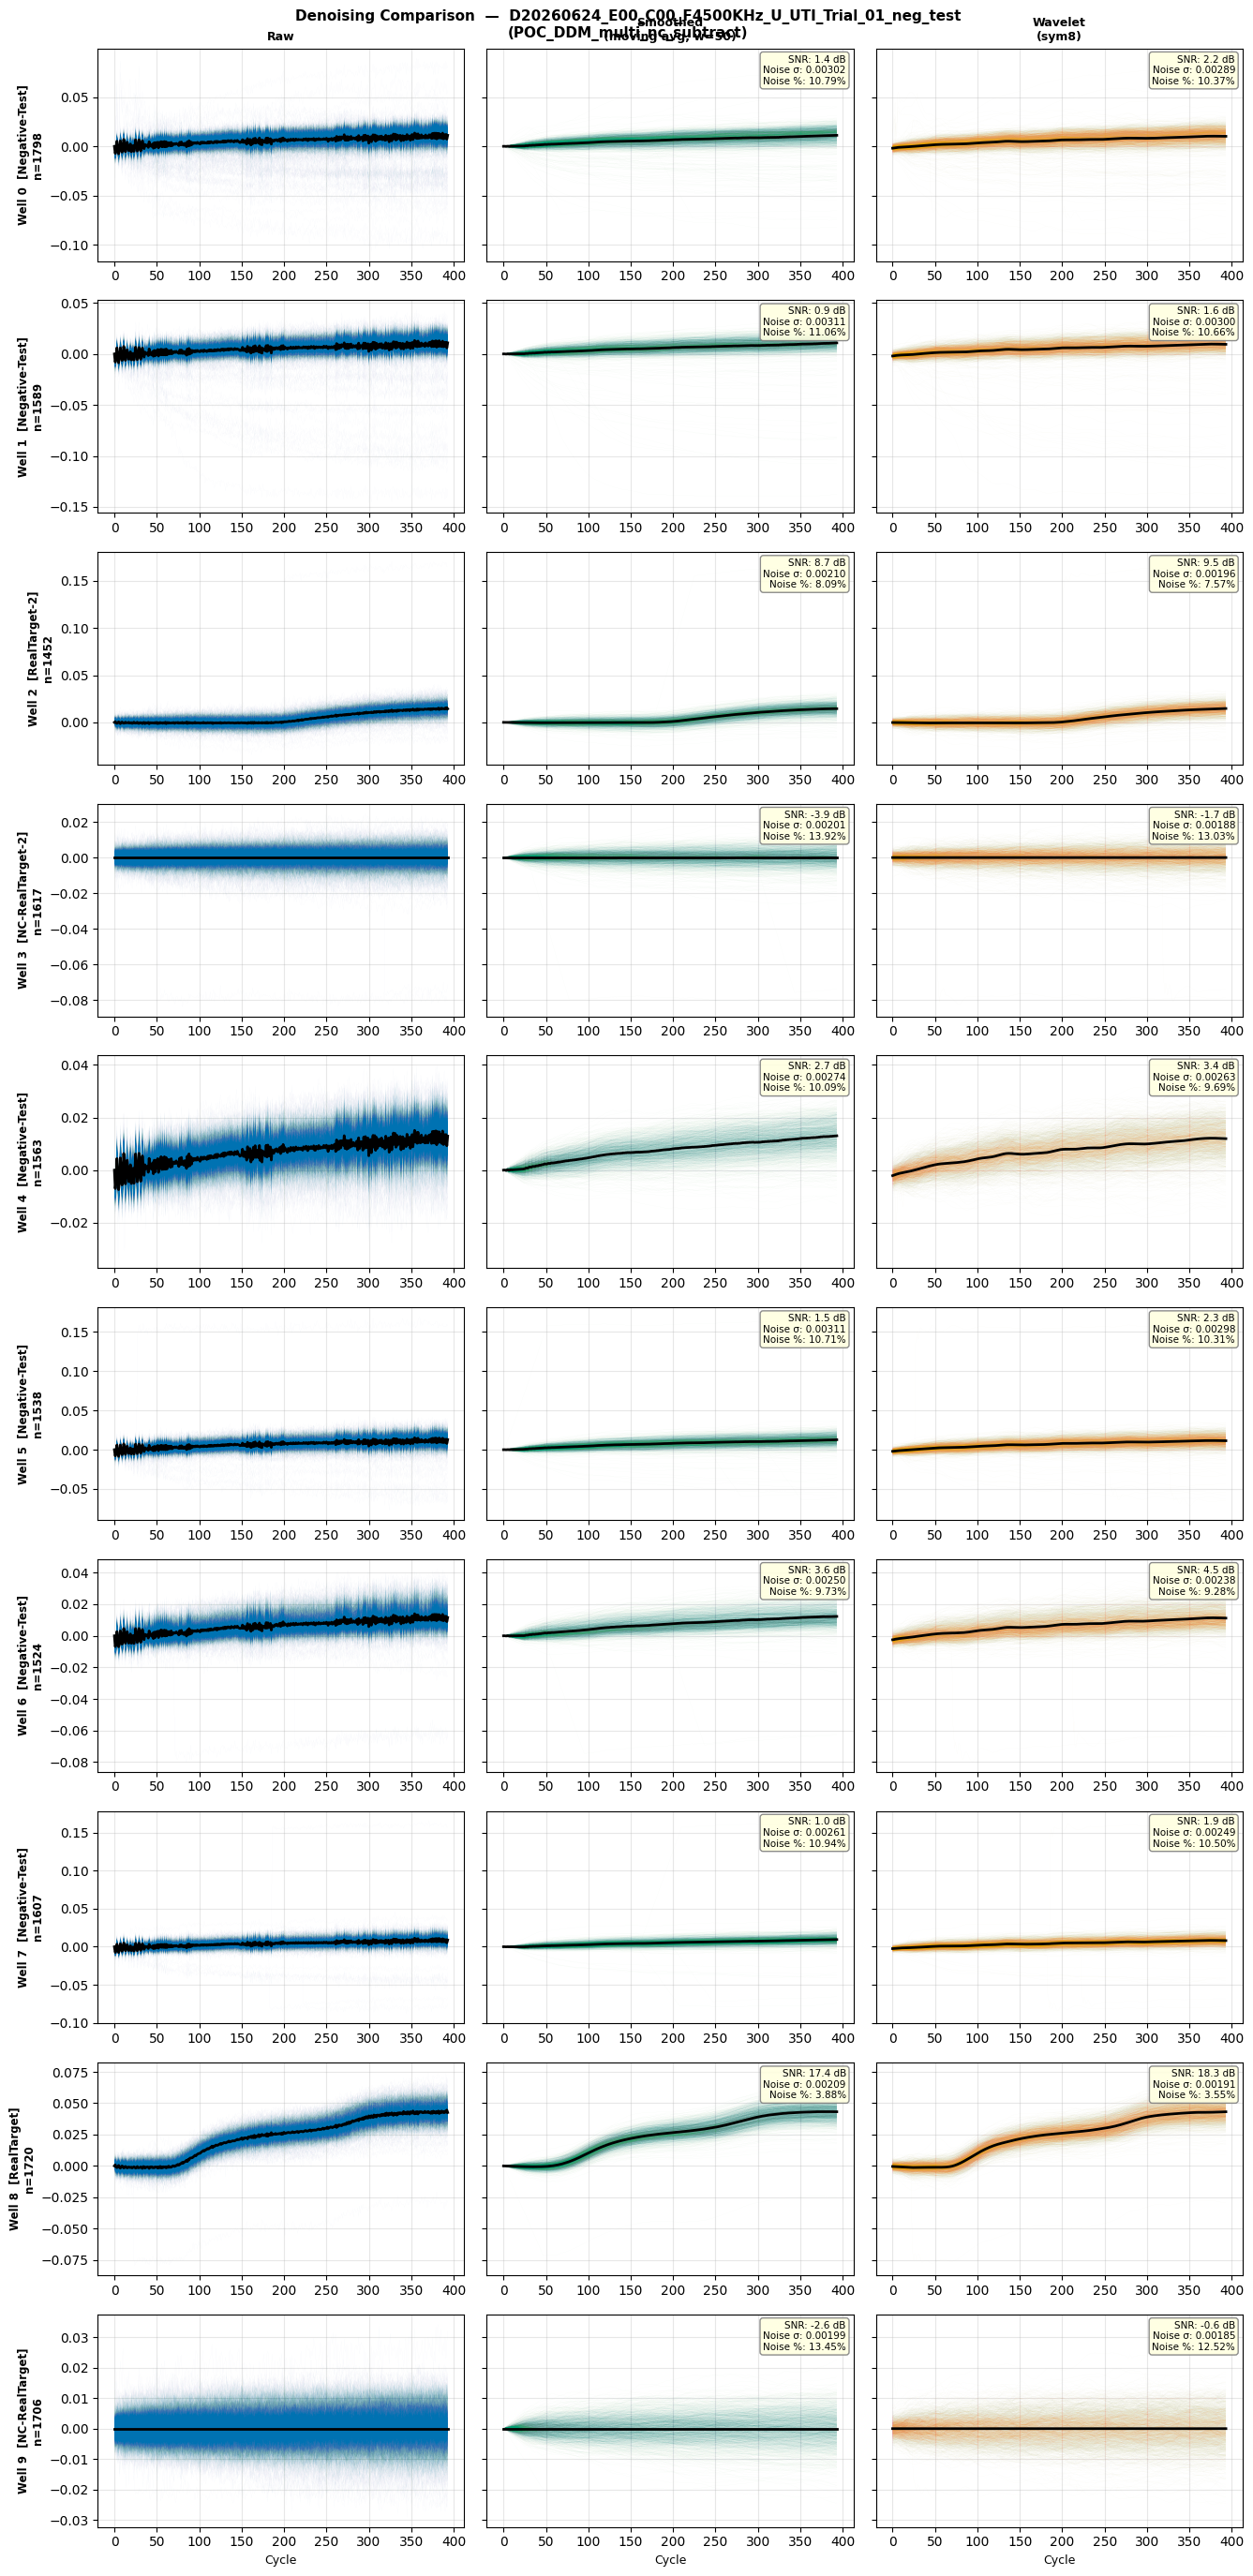

In [7]:
for folder_name in [folders[-1][0]]:
    if folder_name not in results:
        print(f'{folder_name} not in results — run the precompute cell first')
        continue
    r = results[folder_name]
    plot_before_after(
        r['raw'], r['smoothed'], r['denoised'],
        r['well_labels'], folder_name, label_map=r['label_map']
    )

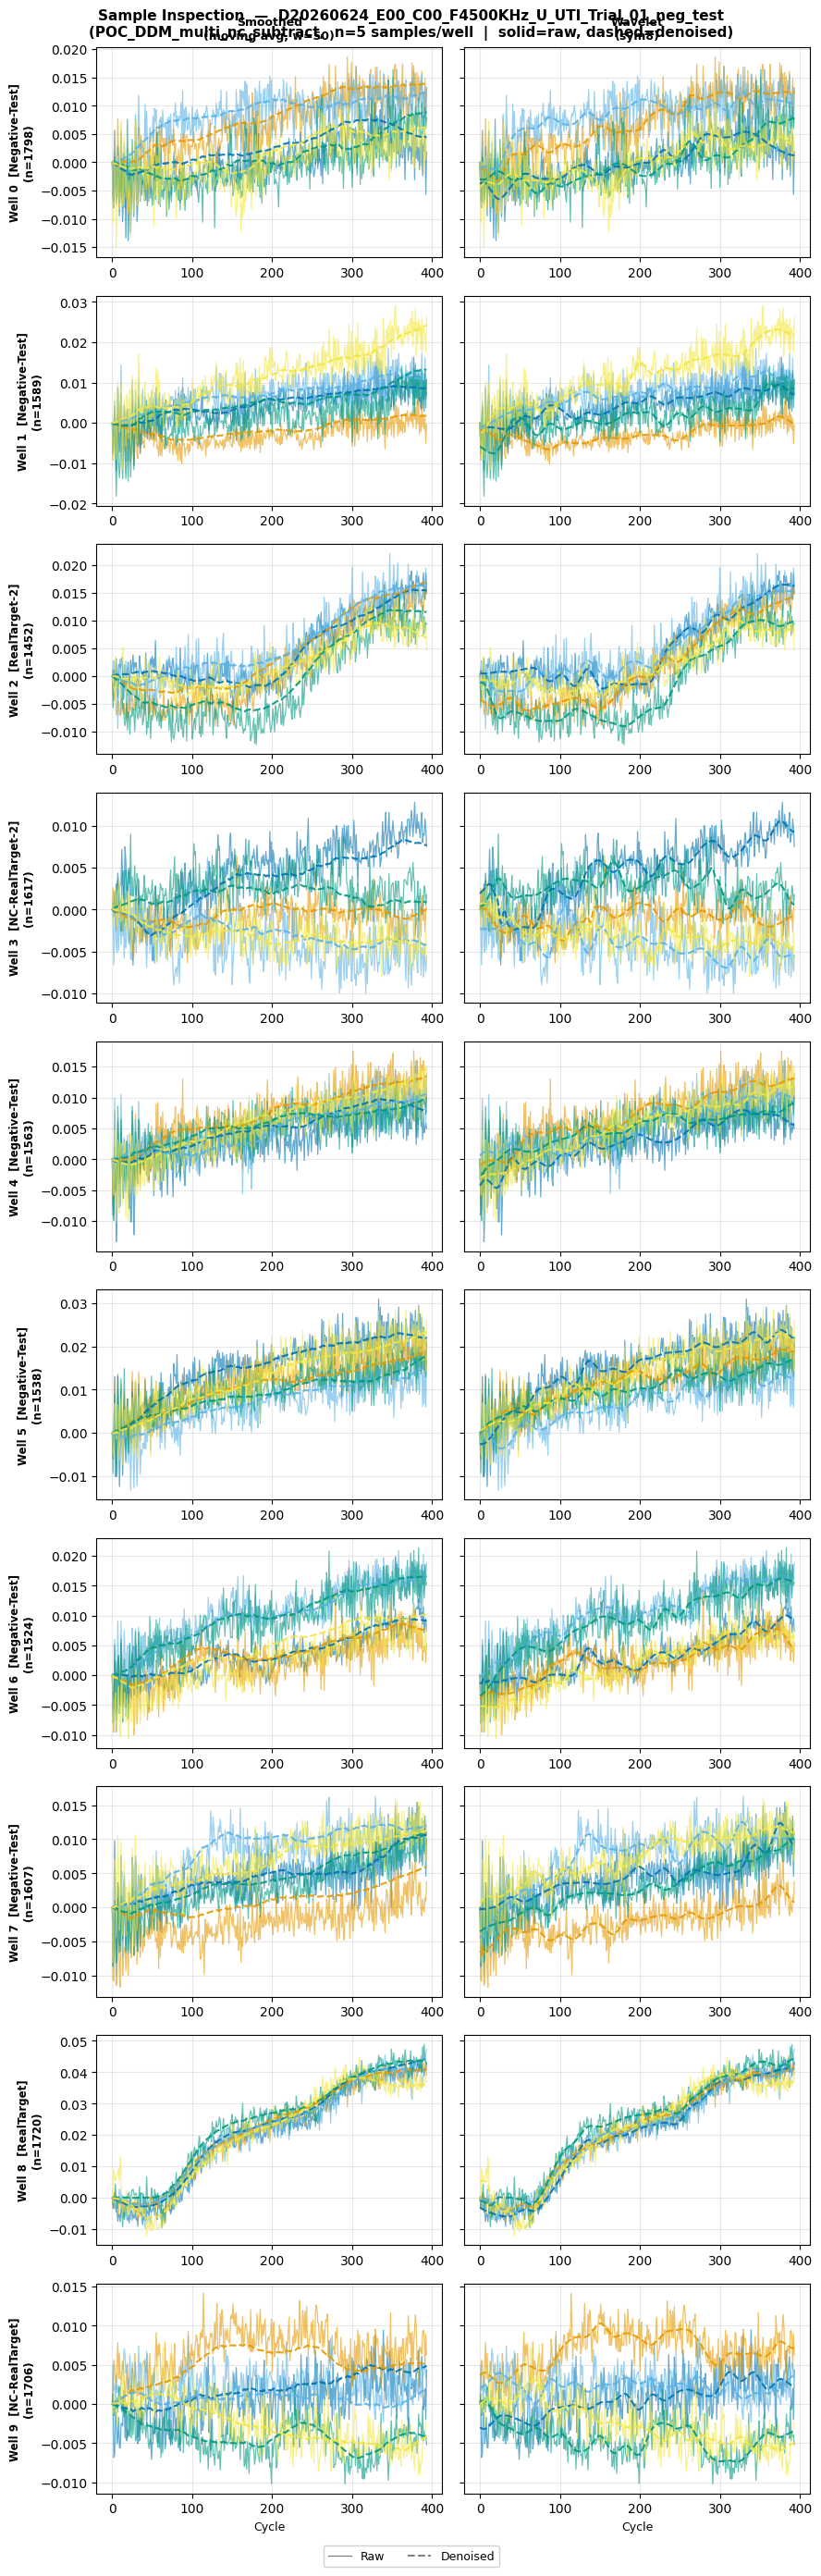

In [8]:
folder_name = list(results.keys())[-1]
plot_sample_inspection(folder_name, n_samples=5, seed=42)


In [9]:
def plot_sample_inspection_by_sample(folder_name, n_samples=5, seed=42):
    """
    Transposed layout vs plot_sample_inspection:
      Columns = individual sampled curves (1 pixel per column)
      Rows    = wells
      Each cell = 1 raw curve (black, solid) + all denoising methods overlaid (colours, dashed)
    """
    r           = results[folder_name]
    raw         = r['raw']
    well_labels = r['well_labels']
    label_map   = r['label_map']

    method_labels  = [f'Smoothed (w={config.WINDOW_SIZE_ORI})'] + [f'Wavelet ({w})' for w in WAVELETS]
    method_arrays  = [r['smoothed']] + [r['denoised'][w] for w in WAVELETS]
    palette        = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors  = [palette[i % len(palette)] for i in range(len(method_labels))]

    unique_wells = sorted(np.unique(well_labels))
    n_rows = len(unique_wells)
    n_cols = n_samples
    x      = np.arange(raw.shape[1])
    rng    = np.random.default_rng(seed)

    # Sample indices per well (same indices reused across all columns)
    well_samples = {}
    for well in unique_wells:
        indices = np.where(well_labels == well)[0]
        n = min(n_samples, len(indices))
        well_samples[well] = rng.choice(indices, size=n, replace=False)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(8.0 * n_cols, 2.8 * n_rows),
        # sharey='row', 
        squeeze=False
    )
    fig.suptitle(
        f'Sample Inspection (per-curve)  —  {folder_name}\n'
        f'({DATASET},  n={n_samples} samples/well  |  black solid=raw)',
        fontsize=11, fontweight='bold'
    )

    for row_i, well in enumerate(unique_wells):
        sampled   = well_samples[well]
        lname     = label_map.get(int(well), '?') if label_map else str(well)
        row_label = f'Well {well}  [{lname}]\n(n={np.sum(well_labels == well)})'

        for col_i, idx in enumerate(sampled):
            ax = axes[row_i, col_i]

            # Raw — black solid, behind everything
            ax.plot(x, raw[idx], color='black', lw=1.0, ls='-', alpha=0.5, zorder=2,
                    label='Raw' if (row_i == 0 and col_i == 0) else '_')

            # Each denoising method — different colour, dashed
            for method_label, den_all, color in zip(method_labels, method_arrays, method_colors):
                ax.plot(x, den_all[idx], color=color, lw=1.4, ls='--', zorder=3,
                        label=method_label if (row_i == 0 and col_i == 0) else '_')

            ax.grid(alpha=0.3)

            if row_i == 0:
                ax.set_title(f'Sample {col_i + 1}', fontweight='bold', fontsize=9)
            if col_i == 0:
                ax.set_ylabel(row_label, fontsize=8.5, fontweight='bold')
            if row_i == n_rows - 1:
                ax.set_xlabel('Cycle', fontsize=9)

    # Shared legend from the first axes (only cell with real labels)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(method_labels) + 1,
               fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    fig.tight_layout()
    plt.show()
    plt.close(fig)


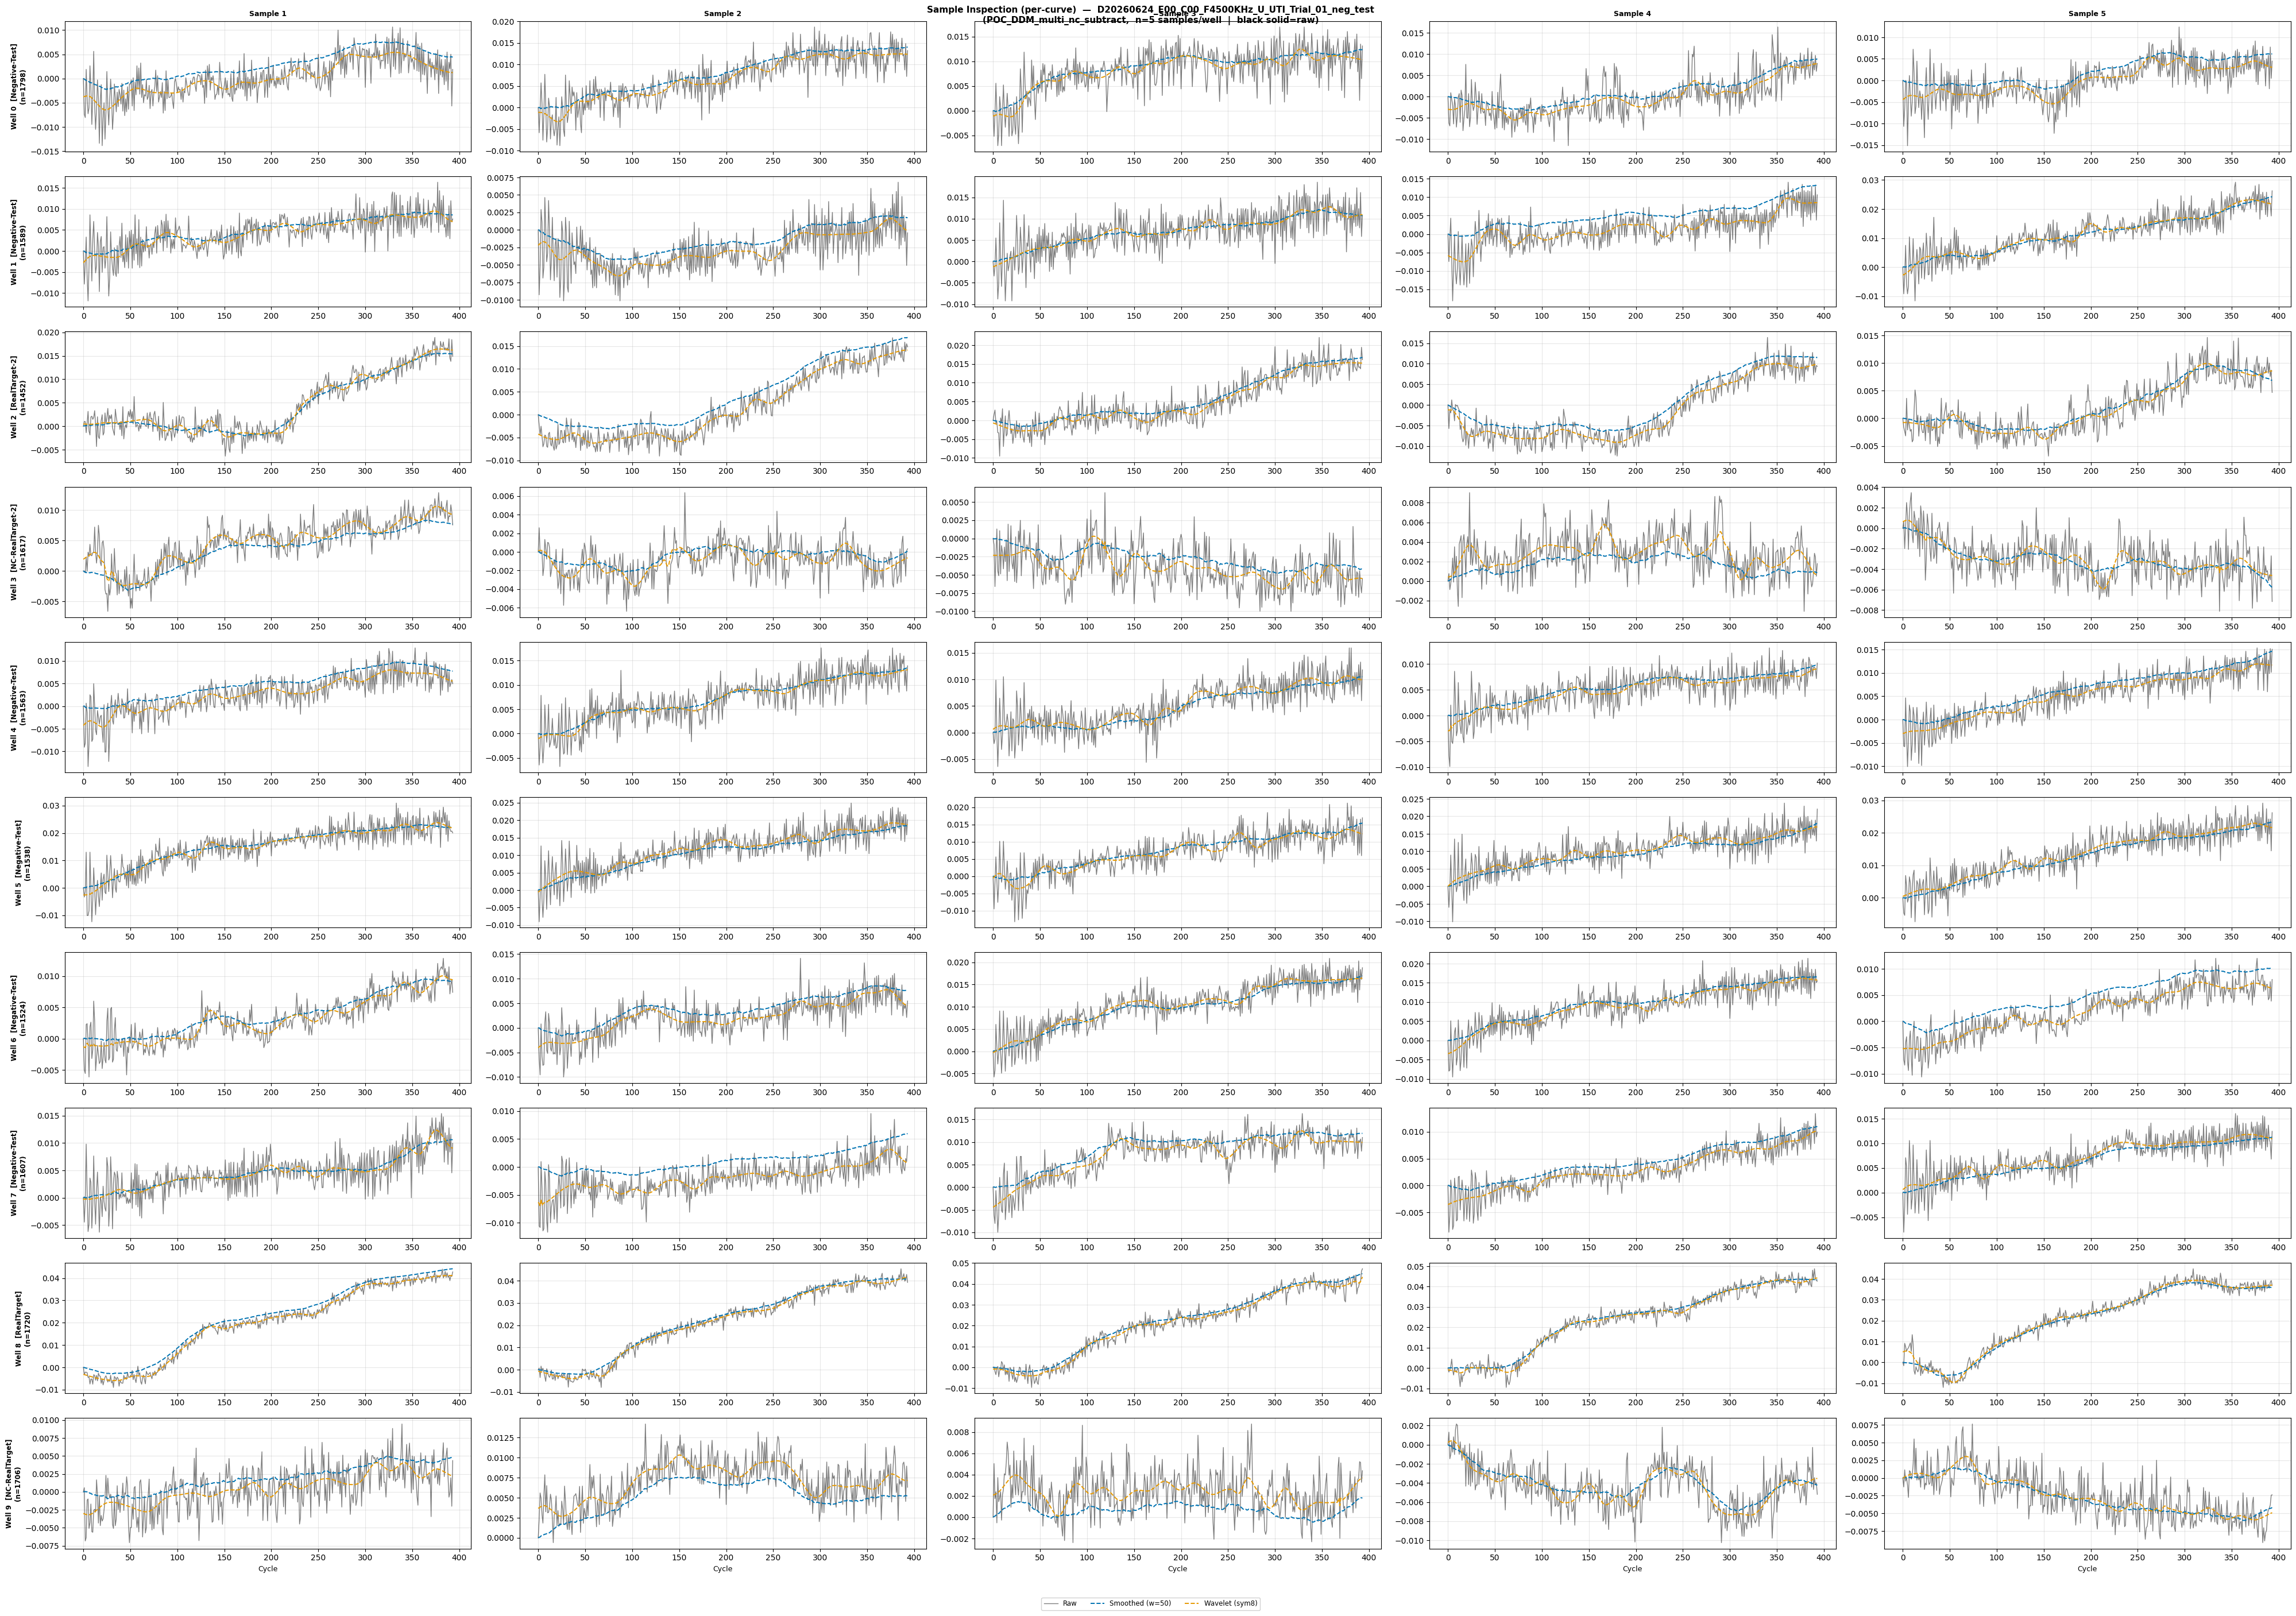

In [10]:
folder_name = list(results.keys())[-1]
plot_sample_inspection_by_sample(folder_name, n_samples=5, seed=42)


In [11]:
from scipy.stats import pearsonr

def compare_methods(folder_name, max_lag=20):
    """
    Computes per-well, per-method summary metrics and plots them.
    Metrics:
      - mean SNR (dB)
      - noise %
      - signal fidelity (corr raw vs denoised)
      - residual autocorrelation at lag 1 (low = noise-like residual = good)
      - smoothness ratio: TV(denoised) / TV(raw)  (< 1 = smoother)
    """
    r           = results[folder_name]
    raw         = r['raw']
    well_labels = r['well_labels']

    method_labels = [f'Smoothed\n(w={config.WINDOW_SIZE_ORI})'] + [f'Wavelet\n({w})' for w in WAVELETS]
    method_arrays = [r['smoothed']] + [r['denoised'][w] for w in WAVELETS]

    def total_variation(arr):
        return np.abs(np.diff(arr, axis=1)).sum(axis=1)

    def residual_autocorr_lag1(raw_w, den_w):
        residuals = raw_w - den_w
        # Mean autocorrelation at lag 1 across all curves
        ac = []
        for res in residuals:
            res = res - res.mean()
            if res.std() == 0:
                continue
            ac.append(np.corrcoef(res[:-1], res[1:])[0, 1])
        return np.mean(ac)

    metric_names = ['SNR (dB)', 'Noise %', 'Fidelity\n(corr)', 'Residual\nautocorr lag-1', 'Smoothness\nratio TV']
    n_methods = len(method_labels)
    n_metrics = len(metric_names)

    # Aggregate across all wells for simplicity (mean over all curves)
    scores = np.zeros((n_metrics, n_methods))

    for mi, den_all in enumerate(method_arrays):
        noise    = raw - den_all
        noise_std = np.std(noise, axis=1)
        sig_range = raw.max(axis=1) - raw.min(axis=1)
        var_d    = np.var(den_all, axis=1)
        var_n    = np.var(noise, axis=1)

        snr      = np.where(var_n > 0, 10 * np.log10(var_d / var_n), np.inf)
        npct     = np.where(sig_range > 0, noise_std / sig_range * 100, 0)
        fidelity = np.array([pearsonr(raw[i], den_all[i])[0] for i in range(len(raw))])
        tv_ratio = total_variation(den_all) / np.where(total_variation(raw) > 0, total_variation(raw), 1)
        ac_lag1  = residual_autocorr_lag1(raw, den_all)

        scores[0, mi] = np.nanmean(snr)
        scores[1, mi] = np.nanmean(npct)
        scores[2, mi] = np.nanmean(fidelity)
        scores[3, mi] = ac_lag1
        scores[4, mi] = np.nanmean(tv_ratio)

    # Plot
    fig, axes = plt.subplots(1, n_metrics, figsize=(4.5 * n_metrics, 5))
    fig.suptitle(f'Method Comparison  —  {folder_name}', fontsize=12, fontweight='bold')

    palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
    colors  = [palette[i % len(palette)] for i in range(n_methods)]
    x       = np.arange(n_methods)
    tick_labels = [l.replace('\n', ' ') for l in method_labels]

    for ax, metric_name, vals in zip(axes, metric_names, scores):
        bars = ax.bar(x, vals, color=colors, edgecolor='black', zorder=3)
        # Highlight best bar
        best_idx = np.argmin(vals) if metric_name.startswith('Residual') or metric_name.startswith('Smooth') \
                   else np.argmax(vals)
        bars[best_idx].set_edgecolor('red')
        bars[best_idx].set_linewidth(2.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
        ax.set_title(metric_name, fontweight='bold', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    # Best direction annotations
    axes[0].set_ylabel('↑ higher = better', fontsize=8, color='gray')
    axes[3].set_ylabel('↓ lower = better', fontsize=8, color='gray')
    axes[4].set_ylabel('↓ lower = smoother', fontsize=8, color='gray')
    # Red outline = best
    fig.text(0.99, 0.01, '■ red outline = best for that metric',
             ha='right', fontsize=8, color='red', style='italic')

    fig.tight_layout()
    plt.show()
    plt.close(fig)


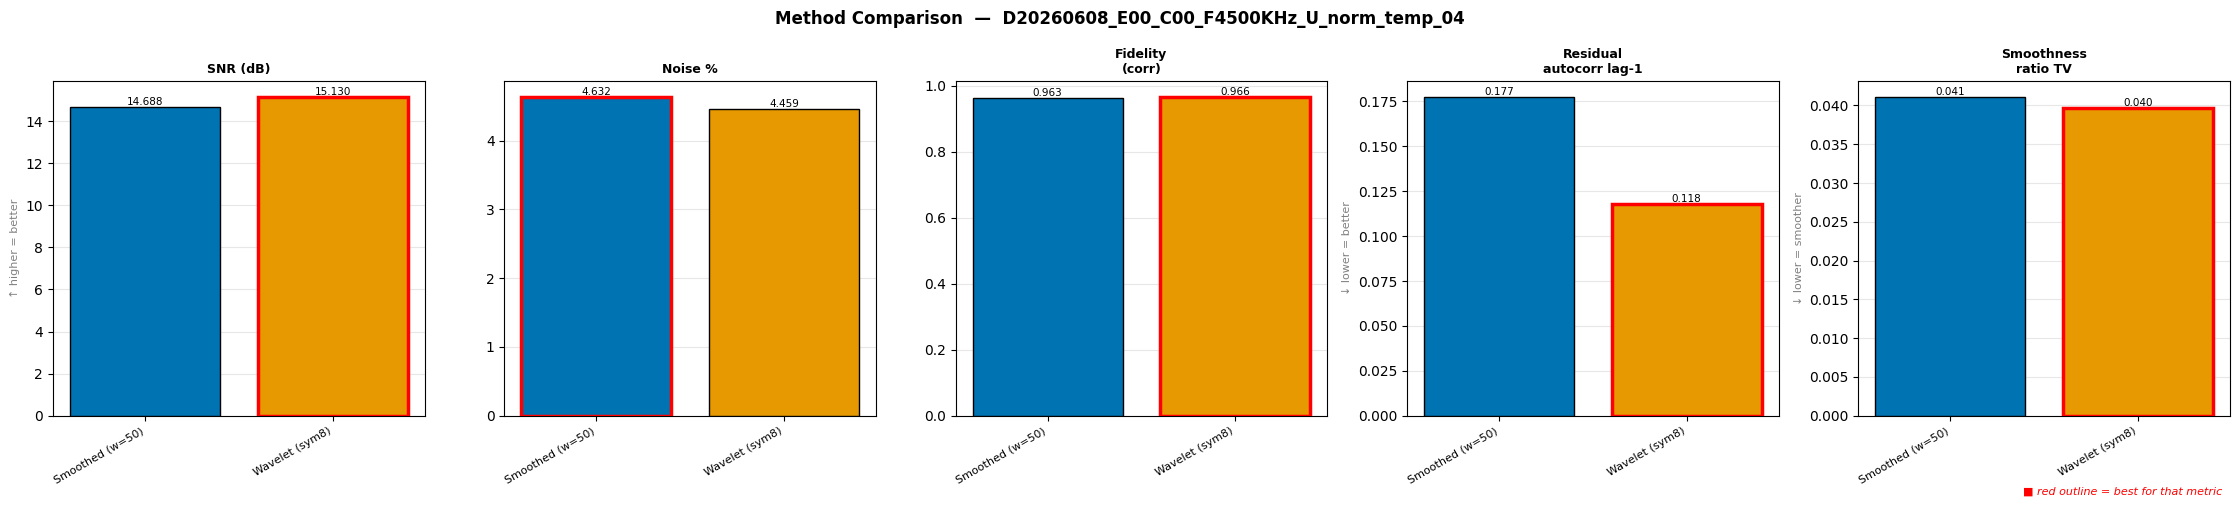

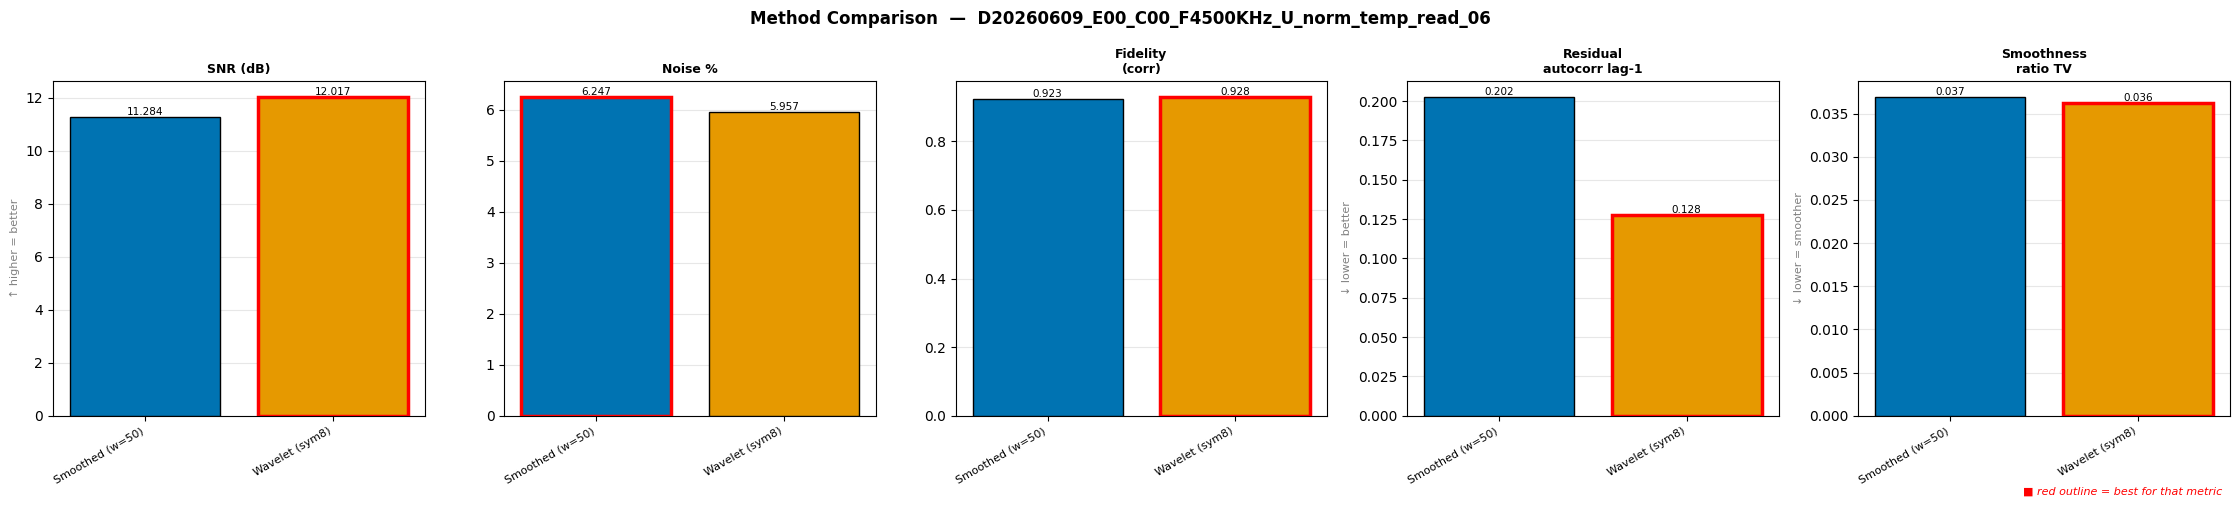

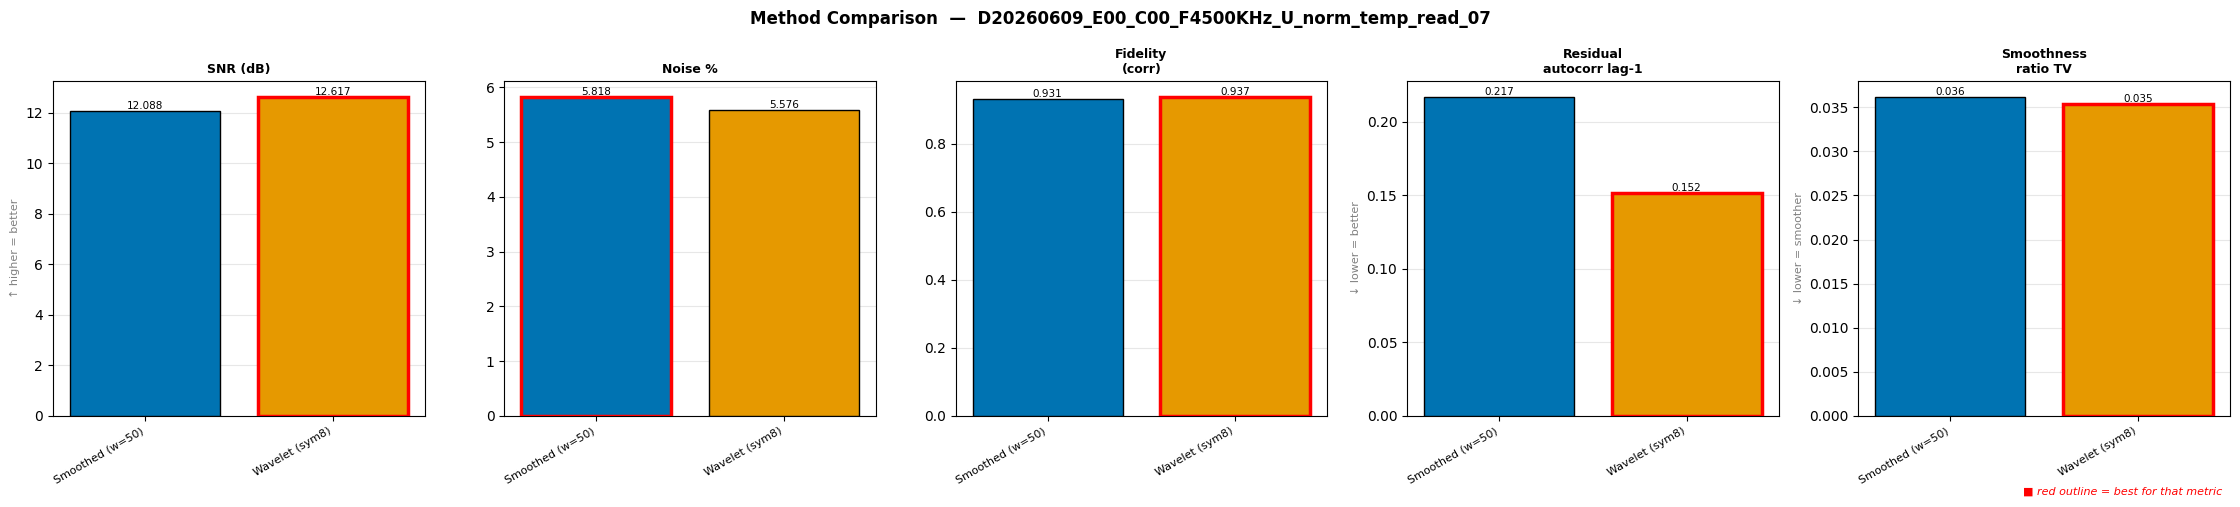

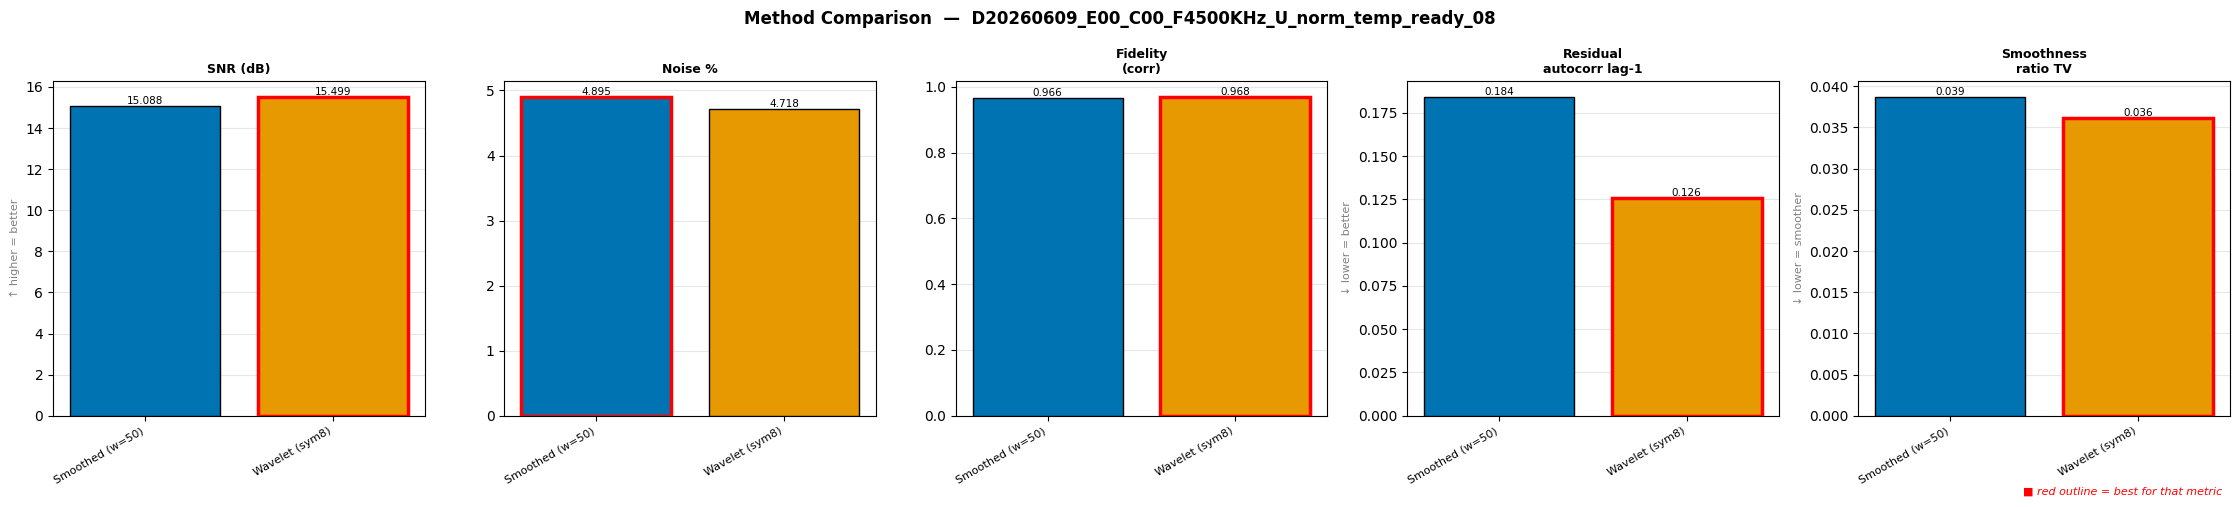

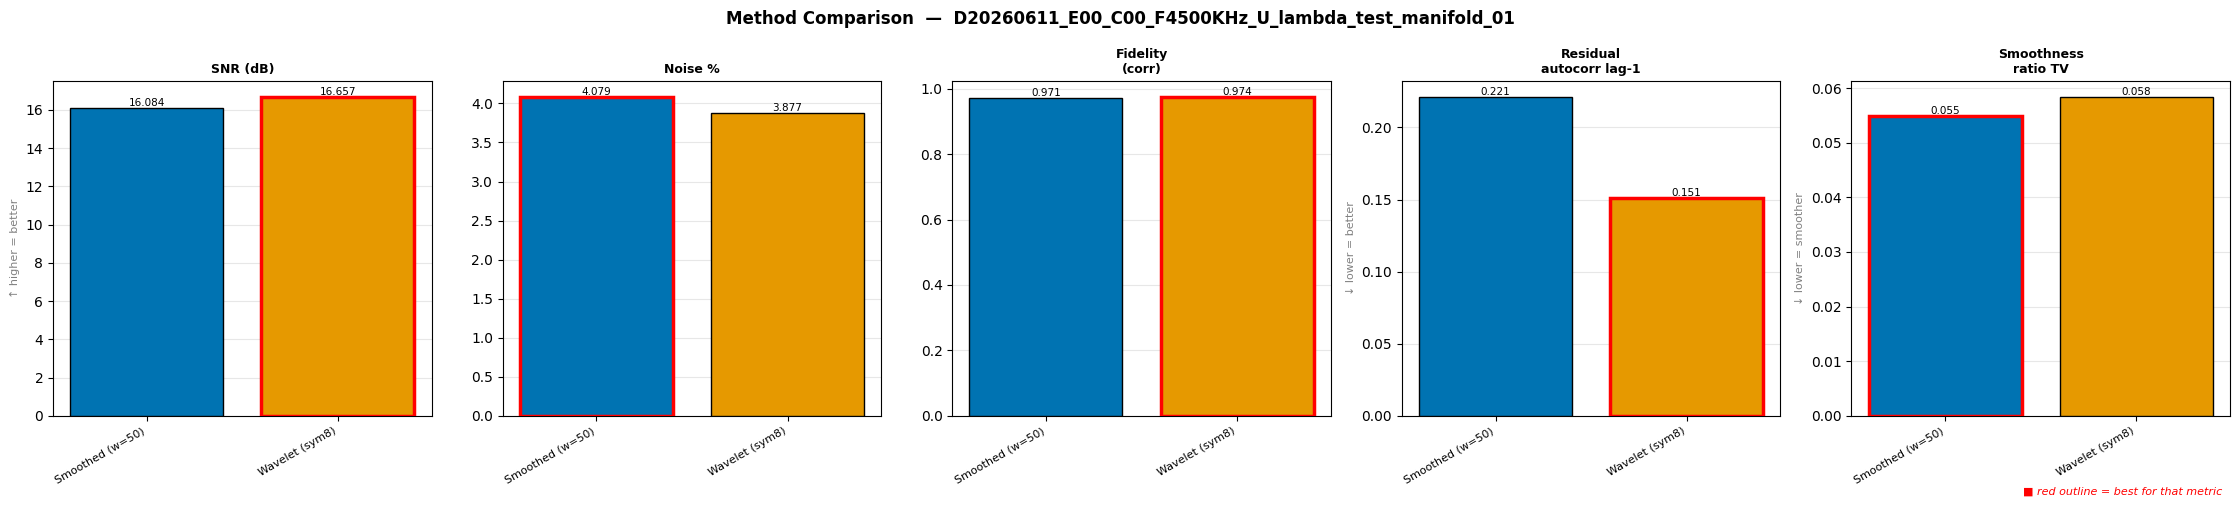

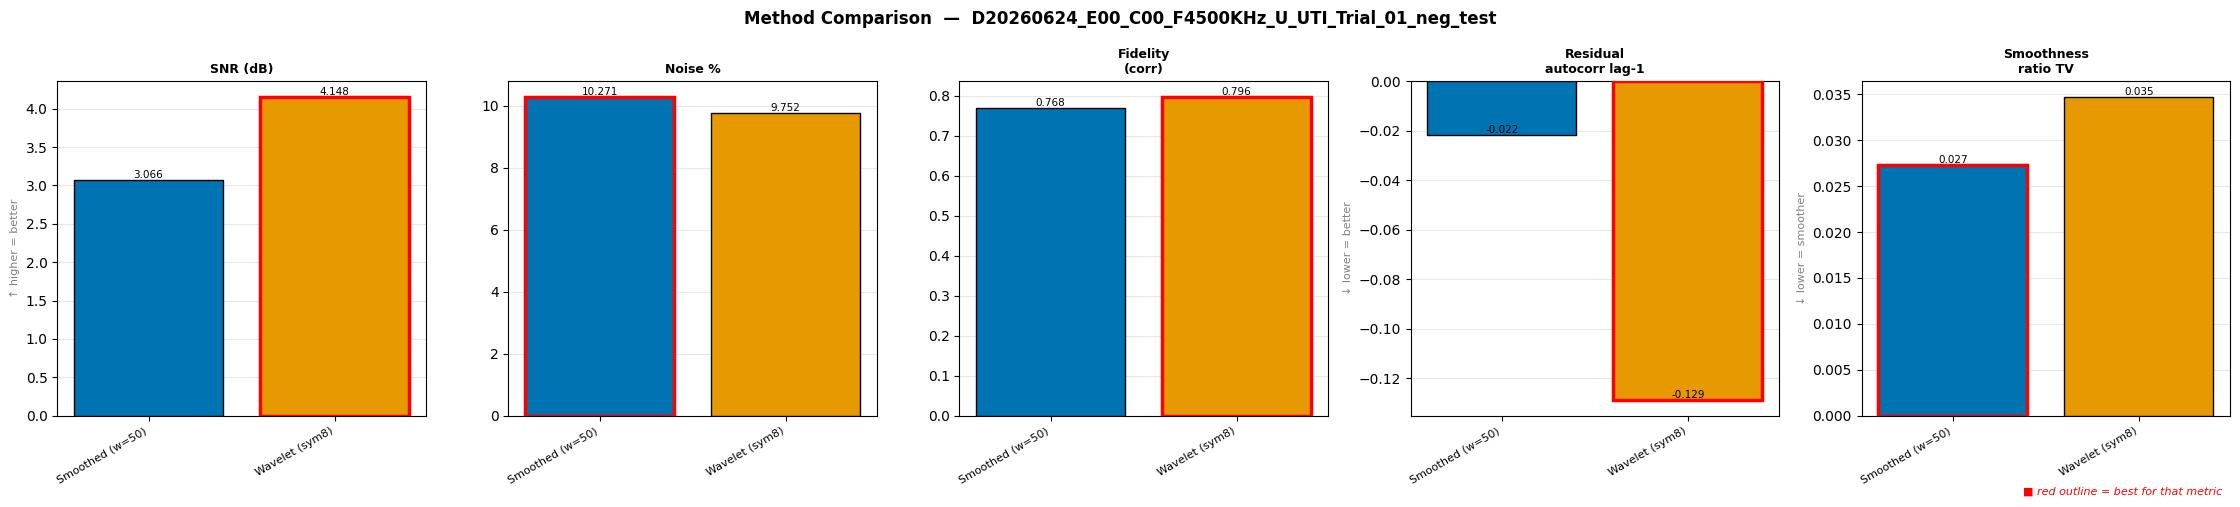

In [12]:
for folder_name in results:
    compare_methods(folder_name)
